# ezcal quick tour

`ezcal` (Easy Calculation) turns a bare crystal structure into a finished
first-principles calculation with one command.  This notebook shows the
Python API behind the CLI:

1. get a structure (local CIF or Materials Project)
2. look at what ezcal would do (symmetry, k-mesh, pseudopotentials, cutoffs)
3. run a full `relax -> scf -> nscf -> dos -> bands` workflow
4. draw the results with matplotlib and plotly
5. do the same thing with a machine-learning potential (SevenNet)

Kernel: `/home/tajimamainpc/.venv/ezcalenv312`

In [1]:
import os, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import ezcal
from ezcal.config import load_config
from ezcal.structures import read_structure, standardize, structure_info, auto_kmesh, band_path
from ezcal.pseudo import PseudoManager
from ezcal.workflows import Workflow

print('ezcal', ezcal.__version__)
WORK = Path('..').resolve() / '02_ezcal_test' / 'notebook_runs'
WORK.mkdir(parents=True, exist_ok=True)
WORK

ezcal 0.1.0


PosixPath('/home/tajimamainpc/06_claude_code/08_qez/02_ezcal_test/notebook_runs')

## 1. Materials Project API key

The key is typed here rather than stored in the repository.
Leave it empty to skip the download and use the local CIF files instead.

In [2]:
import getpass

MP_API_KEY = os.environ.get('MP_API_KEY') or getpass.getpass('Materials Project API key (blank to skip): ')
os.environ['MP_API_KEY'] = MP_API_KEY
print('key set' if MP_API_KEY else 'no key - local structures will be used')

key set


In [3]:
if MP_API_KEY:
    structure = read_structure('mp-149', api_key=MP_API_KEY)   # Si
else:
    structure = read_structure('../02_ezcal_test/structures/Si.cif')

structure = standardize(structure, primitive=True)
structure

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Structure Summary
Lattice
    abc : 3.849278862666787 3.849278862666787 3.8492788626667873
 angles : 59.999999999999986 59.999999999999986 59.999999999999986
 volume : 40.329526847420134
      A : 4.377070542011193e-16 2.7218511864697263 2.7218511864697263
      B : 2.7218511864697263 0.0 2.7218511864697263
      C : 2.721851186469727 2.7218511864697263 3.333306343265576e-16
    pbc : True True True
PeriodicSite: Si (1.361, 1.361, 1.361) [0.25, 0.25, 0.25]
PeriodicSite: Si (3.022e-16, 1.037e-16, 1.985e-16) [0.0, 7.293e-17, 3.809e-17]

## 2. What will ezcal do?

Cutoffs come from the pseudopotential headers, the k-mesh from a
reciprocal-space spacing, and the band path from seekpath - nothing has to
be looked up by hand.

In [4]:
info = structure_info(structure)
print(json.dumps(info, indent=2))
print('k-mesh @ kspacing=0.25 :', auto_kmesh(structure, 0.25))

pm = PseudoManager(functional='pbe')
pseudos = pm.resolve_all([str(el) for el in structure.composition.elements])
for element, p in pseudos.items():
    print(f'{element:3s} {p.filename}  type={p.pseudo_type} Z={p.z_valence:g} ecutwfc={p.ecutwfc} Ry')
print('suggested cutoffs:', PseudoManager.suggest_cutoffs(pseudos.values()))

{
  "formula": "Si",
  "full_formula": "Si2",
  "natoms": 2,
  "nelements": 1,
  "elements": [
    "Si"
  ],
  "volume": 40.329527,
  "density": 2.3128,
  "lattice": {
    "a": 3.849279,
    "b": 3.849279,
    "c": 3.849279,
    "alpha": 60.0,
    "beta": 60.0,
    "gamma": 60.0
  },
  "spacegroup": "Fd-3m",
  "spacegroup_number": 227,
  "crystal_system": "cubic"
}
k-mesh @ kspacing=0.25 : [8, 8, 8]
Si  Si.pbe-n-kjpaw_psl.1.0.0.UPF  type=PAW Z=4 ecutwfc=44.0 Ry
suggested cutoffs: (44.0, 352.0)


In [5]:
bp = band_path(structure)
print(bp.nkpt, 'k-points')
print(' -> '.join(dict.fromkeys(l for _, l in bp.labels if l)))

131 k-points
Γ -> X -> U -> K -> L -> W


## 3. Run the whole workflow

`Workflow.run('auto')` chains `vc-relax -> scf -> nscf -> dos -> bands`,
reusing one charge density.  The settings below are deliberately loose so
that the notebook finishes in about a minute on 8 cores.

In [6]:
cfg = load_config()
cfg.apply_overrides({
    'run.nproc': 8,
    'dft.ecutwfc': 30, 'dft.ecutrho': 240,
    'dft.kmesh': [6, 6, 6],
    'dft.conv_thr': 1e-6,
    'output.plot': ['both'],
})

wf = Workflow(cfg, structure, WORK / 'Si_auto', label='Si', log=print)
result = wf.run('auto')
print('ok:', result.ok)
for name in result.order:
    s = result.steps[name]
    print(f'{name:10s} E={s.energy} eV  E_F={s.fermi_energy} eV  gap={s.band_gap}')

[1/5] vc-relax: cell + ionic relaxation


    k-path (131 points): Γ -> X -> U -> K -> L -> W
[2/5] scf: self-consistent field


[3/5] nscf: non self-consistent (dense mesh)


[4/5] dos: density of states


[5/5] bands: band structure


ok: True
vc-relax   E=-1271.4837648751097 eV  E_F=6.009800969712159 eV  gap=0.7431388539738242
scf        E=-1271.4837831617583 eV  E_F=6.027780551383803 eV  gap=0.7386119669069986
nscf       E=None eV  E_F=6.473432409744971 eV  gap=0.5983601835643375
dos        E=None eV  E_F=6.473 eV  gap=None
bands      E=None eV  E_F=6.473432409744971 eV  gap=0.5989030061645026


In [7]:
print(json.dumps(result.summary()['steps'], indent=2)[:2000])

{
  "vc-relax": {
    "task": "vc-relax",
    "engine": "qe",
    "ok": true,
    "converged": true,
    "energy": -1271.4837648751097,
    "energy_per_atom": -635.7418824375549,
    "fermi_energy": 6.009800969712159,
    "band_gap": 0.7431388539738242,
    "homo": 6.033441581843455,
    "lumo": 6.776580435817279,
    "magnetization": null,
    "max_force": 0.0,
    "pressure": 0.33488316064548157,
    "nelec": 8.0,
    "nbnd": 8,
    "kmesh": [
      6,
      6,
      6
    ],
    "nkpt": 16,
    "walltime": 39.94,
    "job_id": null,
    "submitted_only": false,
    "workdir": "/home/tajimamainpc/06_claude_code/08_qez/02_ezcal_test/notebook_runs/Si_auto/00_vc-relax",
    "files": {
      "input": "/home/tajimamainpc/06_claude_code/08_qez/02_ezcal_test/notebook_runs/Si_auto/00_vc-relax/vc-relax.in",
      "output": "/home/tajimamainpc/06_claude_code/08_qez/02_ezcal_test/notebook_runs/Si_auto/00_vc-relax/vc-relax.out",
      "xml": "/home/tajimamainpc/06_claude_code/08_qez/02_ezcal_tes

## 4. Draw the results

The workflow already wrote PNG and interactive HTML into `plots/`.
The same helpers can be called directly to draw inside the notebook.

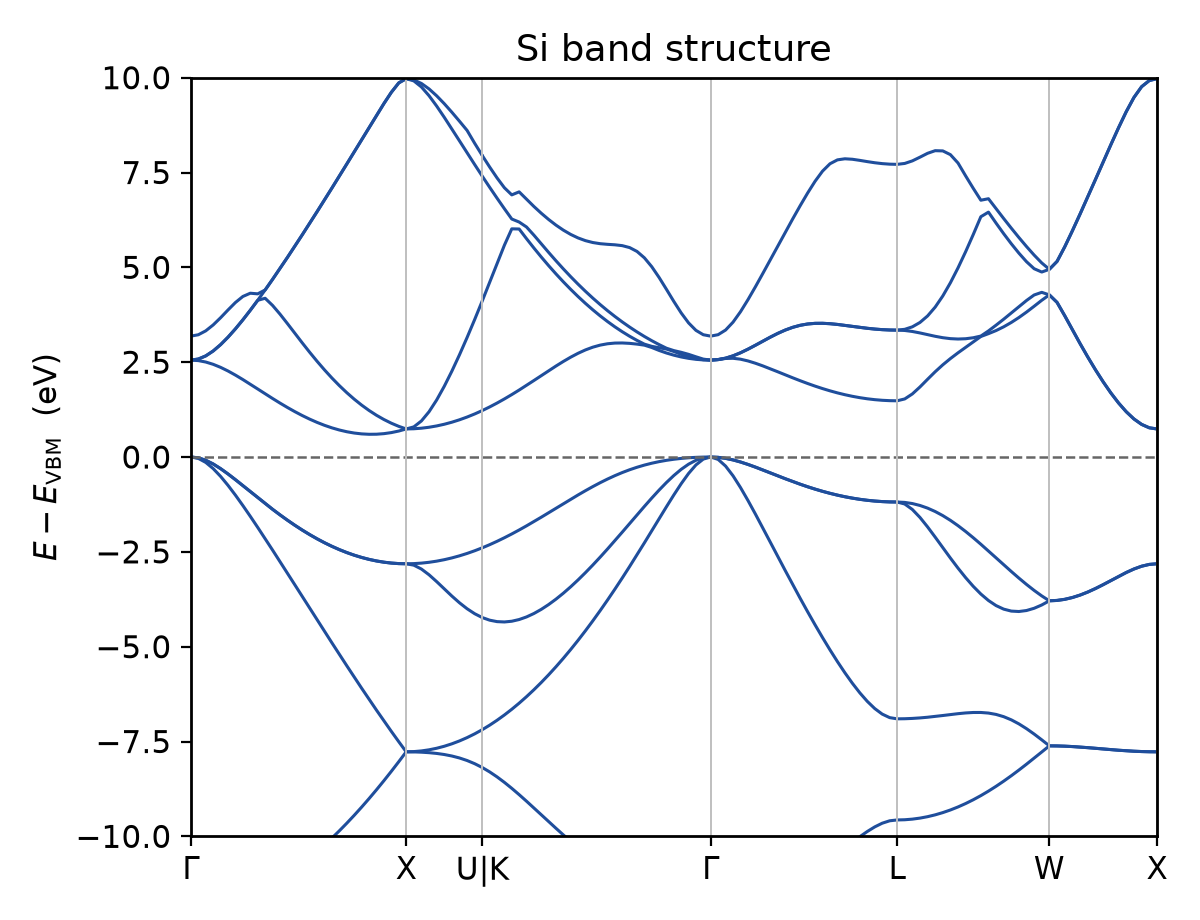

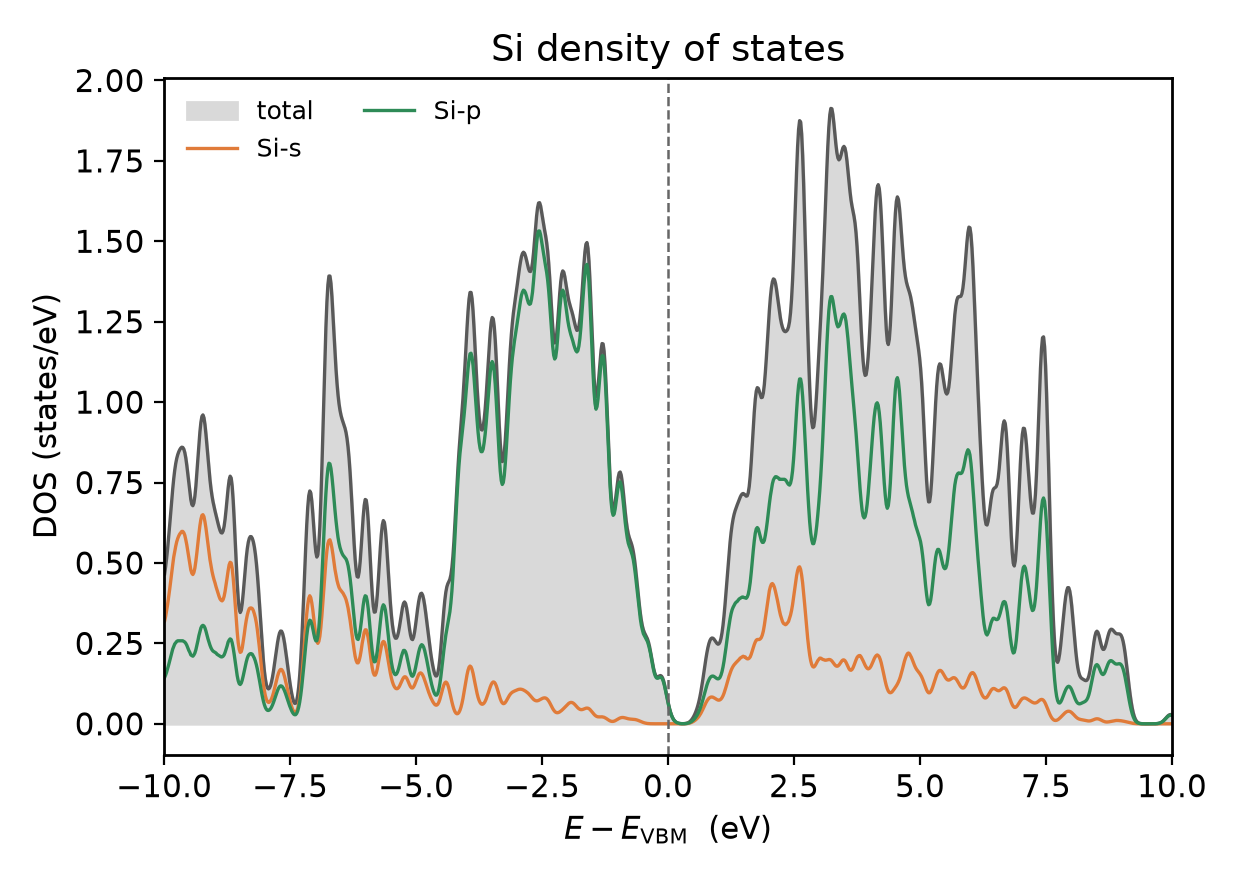

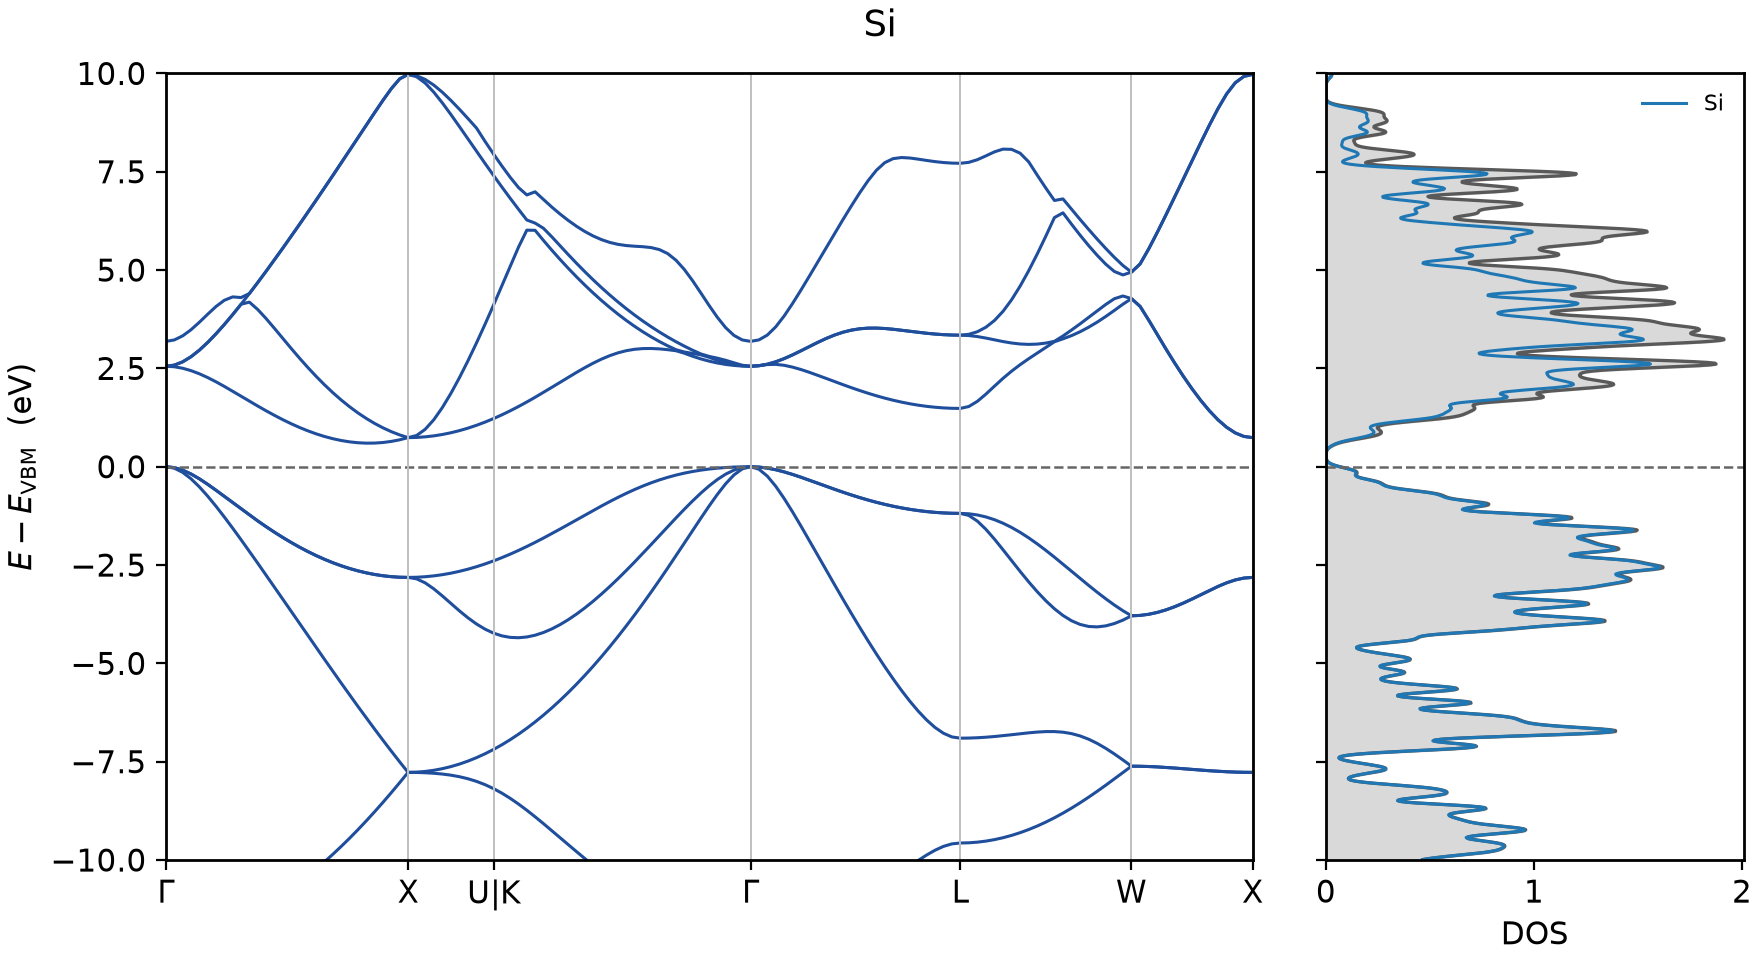

In [8]:
from IPython.display import Image, display

for name in ['bands.png', 'dos.png', 'bands_dos.png']:
    path = wf.rundir / 'plots' / name
    if path.exists():
        display(Image(filename=str(path)))

In [9]:
# interactive plotly version, rendered inline
from ezcal import plotting
import plotly.io as pio

bands, dos = result.steps.get('bands'), result.steps.get('dos')
fermi = (result.steps['bands'].data.get('gap_info') or {}).get('vbm')
arr = plotting.band_arrays(bands, fermi)

import plotly.graph_objects as go
fig = go.Figure()
eig, dist = arr['eigenvalues'], arr['distances']
for b in range(eig.shape[2]):
    fig.add_trace(go.Scatter(x=dist, y=eig[0, :, b] - arr['fermi'], mode='lines',
                             line=dict(color='#1f4e9c', width=1.3), showlegend=False))
ticks, names = plotting._tick_positions(dist, arr['labels'])
fig.update_layout(template='plotly_white', height=460, width=720,
                  yaxis=dict(title='E - E_VBM (eV)', range=[-10, 10]),
                  xaxis=dict(tickvals=ticks, ticktext=names))
fig.show()

## 5. The same structure with a machine-learning potential

SevenNet answers energy / forces / stress in a fraction of a second, which
makes it a good pre-relaxation step before the DFT run.  It cannot do
electronic structure, and ezcal says so rather than producing a wrong plot.

In [10]:
mcfg = load_config()
mcfg.apply_overrides({'engine': 'mlip', 'mlip.model': '7net-0', 'mlip.device': 'cpu'})

mwf = Workflow(mcfg, structure, WORK / 'Si_mlip', label='Si (SevenNet)', log=print)
mres = mwf.run('vc-relax')
step = mres.steps['vc-relax']
print('E/atom  MLIP :', step.energy_per_atom)
print('E/atom  DFT  :', result.steps['scf'].energy_per_atom, '(different reference, do not compare directly)')
print('lattice MLIP :', step.structure.lattice.abc)
print('lattice DFT  :', result.structure_final.lattice.abc)

[1/1] vc-relax: cell + ionic relaxation


/home/tajimamainpc/.venv/ezcalenv312/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/home/tajimamainpc/.venv/ezcalenv312/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


/home/tajimamainpc/.venv/ezcalenv312/lib/python3.12/site-packages/sevenn/calculator.py:93: UserWarning: No tensor product accelerator is enabled for SevenNetCalculator. SevenNet may run much slower without a TP accelerator. Please refer to the accelerator section of the documentation.
  util.warn_no_tp_accelerator('SevenNetCalculator')


E/atom  MLIP : -5.402981758117676
E/atom  DFT  : -635.7418915808792 (different reference, do not compare directly)
lattice MLIP : (3.862688710786289, 3.8626887110691945, 3.862688711600093)
lattice DFT  : (3.8594477226351542, 3.8594477226351542, 3.8594477226351542)


## 6. Submitting to a queue

`scheduler: qsub` renders `run_qe.sh` and submits it.  There is no queue on
this machine, so `run.dry_run` is used to look at the script that *would*
be submitted.

In [11]:
qcfg = load_config()
qcfg.apply_overrides({'run.scheduler': 'qsub', 'run.dry_run': True, 'run.nproc': 16,
                      'run.qsub.queue': 'batch', 'run.qsub.walltime': '12:00:00'})
qwf = Workflow(qcfg, structure, WORK / 'Si_qsub', label='Si', log=print)
qres = qwf.run('scf')
print(open(qwf.rundir / '00_scf' / 'scf.qsub.sh').read())

[1/1] scf: self-consistent field
#!/bin/bash
#PBS -N ezcal_scf
#PBS -l nodes=1:ppn=16
#PBS -l walltime=12:00:00
#PBS -q batch
#PBS -j oe
# ------------------------------------------------------------------
# ezcal qsub template.  ezcal substitutes the double-brace placeholders
# JOB_NAME, NODES, PPN, NPROC, QUEUE, WALLTIME, WORKDIR, MPIRUN,
# OMP_NUM_THREADS and COMMANDS (see ezcal/scheduler.py).
# Copy this file next to your structure and edit it for your site
# (module load, scratch handling, ...); ezcal picks up ./run_qe.sh first.
# ------------------------------------------------------------------

cd "${PBS_O_WORKDIR:-/home/tajimamainpc/06_claude_code/08_qez/02_ezcal_test/notebook_runs/Si_qsub/00_scf}" || exit 1

export OMP_NUM_THREADS=1

# --- site specific setup (edit me) --------------------------------
# module load openmpi
# module load quantum-espresso
# source ~/.venv/ezcalenv312/bin/activate

echo "host      : $(hostname)"
echo "workdir   : $(pwd)"
echo "started   : $(date

## 7. Where everything ended up

Each run directory holds the inputs, the raw QE output, `summary.json`,
`report.md`, `raw_data.json` (for `ezcal plot`) and the figures.

In [12]:
for path in sorted(wf.rundir.rglob('*')):
    if path.is_file() and path.suffix in {'.md', '.json', '.png', '.html', '.csv', '.in'}:
        print(path.relative_to(wf.rundir))

00_vc-relax/vc-relax.in
00_vc-relax/vc-relax_result.json
01_scf/scf.in
01_scf/scf_result.json
02_nscf/nscf.in
02_nscf/nscf_result.json
03_dos/dos.in
03_dos/dos_result.json
03_dos/projwfc.in
04_bands/bands.in
04_bands/bands_result.json
final_structure.json
input_structure.json
plots/bands.csv
plots/bands.html
plots/bands.png
plots/bands_dos.html
plots/bands_dos.png
plots/convergence.html
plots/convergence.png
plots/dos.csv
plots/dos.html
plots/dos.png
raw_data.json
relaxed_structure.json
report.md
summary.json
